# 1 - Carga y Configuracion

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

sns.set_theme(style="whitegrid")

df_pca = pd.read_csv('data/dataset_f1_pca.csv')

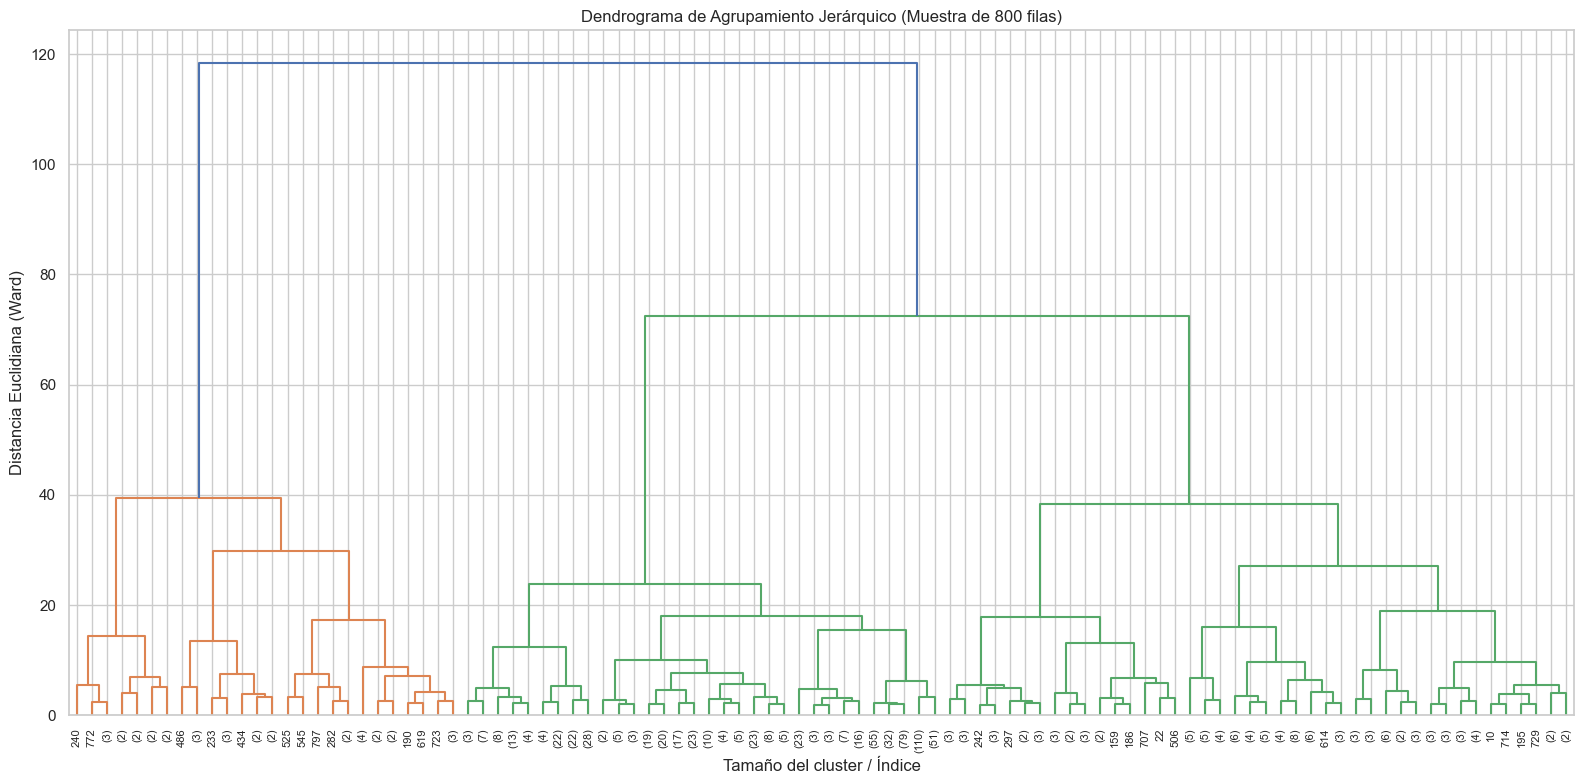

In [57]:
# 1. Tomar una muestra aleatoria de tu dataset con PCA
df_pca_muestra = df_pca.sample(n=800, random_state=42)

# 2. Calcular el linkage SOLO sobre la muestra
plt.figure(figsize=(16, 8))
Z = sch.linkage(df_pca_muestra, method='ward')

# 3. Dibujar el dendrograma (Truncado a 100)
sch.dendrogram(Z, truncate_mode='lastp', p=100, leaf_rotation=90., leaf_font_size=8.)

plt.title('Dendrograma de Agrupamiento Jerárquico (Muestra de 800 filas)')
plt.xlabel('Tamaño del cluster / Índice')
plt.ylabel('Distancia Euclidiana (Ward)')
plt.tight_layout()
plt.show()

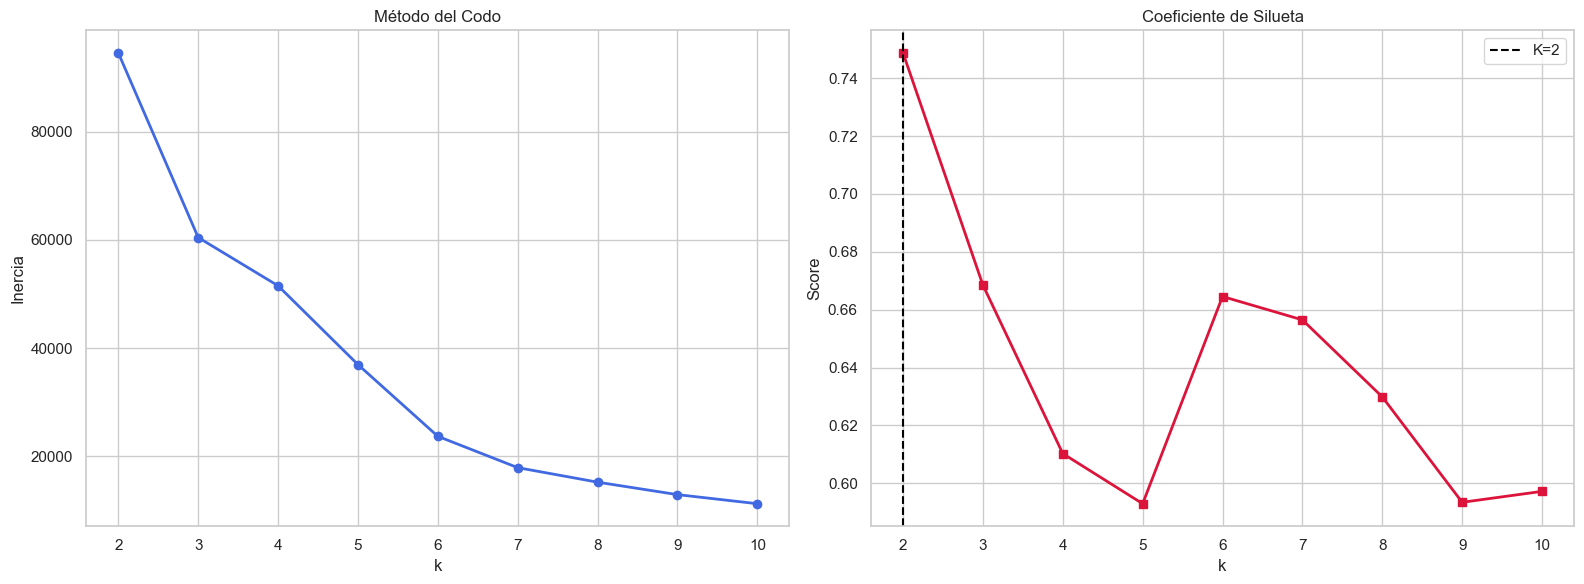

In [65]:
# 3. EVALUACIÓN K-MEANS: CODO Y SILUETA (Optimizada con sample_size)
K_MIN, K_MAX = 2, 10
inercias, siluetas = [], []
rango_k = range(K_MIN, K_MAX + 1)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    etiquetas = kmeans.fit_predict(df_pca)
    
    inercias.append(kmeans.inertia_)
    # El sample_size evita el cuello de botella O(N^2)
    score = silhouette_score(df_pca, etiquetas, sample_size=20000, random_state=42)
    siluetas.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(rango_k, inercias, marker='o', color='royalblue', linewidth=2)
ax1.set_title('Método del Codo')
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')
ax1.set_xticks(rango_k)

ax2.plot(rango_k, siluetas, marker='s', color='crimson', linewidth=2)
ax2.set_title('Coeficiente de Silueta')
ax2.set_xlabel('k')
ax2.set_ylabel('Score')
ax2.set_xticks(rango_k)
ax2.axvline(x=2, color='black', linestyle='--', label='K=2')
ax2.legend()

plt.tight_layout()
plt.show()

In [66]:
# 4. K-MEANS FINAL Y GUARDADO
k_elegido = 2
kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init='auto')
df_pca['Cluster'] = kmeans_final.fit_predict(df_pca)

df_pca.to_csv('data/dataset_f1_clustered.csv', index=False)
print(f"Dataset guardado con {k_elegido} clusters.")

Dataset guardado con 2 clusters.


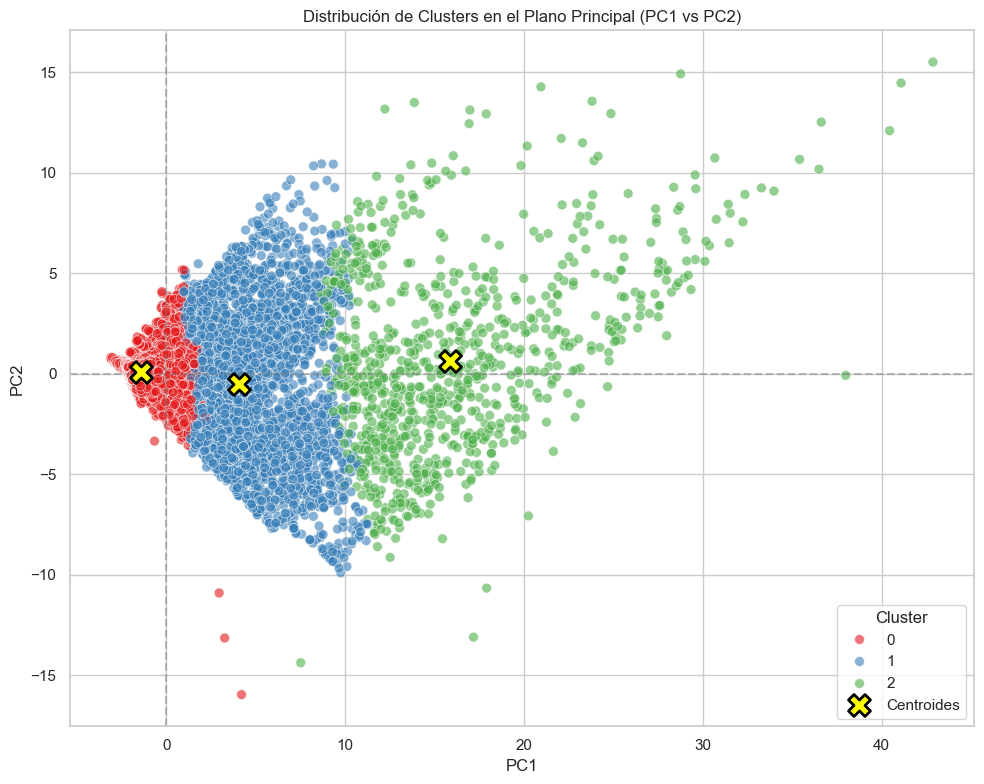

In [51]:
# 5. VISUALIZACIÓN DE CLUSTERS (PC1 vs PC2)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='Set1', data=df_pca, alpha=0.6, s=50)

centroides = kmeans_final.cluster_centers_
plt.scatter(
    centroides[:, 0], centroides[:, 1], 
    s=250, c='yellow', marker='X', edgecolors='black', 
    linewidths=2, label='Centroides', zorder=10
)

plt.title('Distribución de Clusters en el Plano Principal (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()